In [1]:
from forestkernel import ForestKernel
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
from dataset import dataprep

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import time
import numpy as np
from sklearn.decomposition import PCA
from openTSNE import TSNE



from time import time

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from umap import UMAP

timings = {}

# ---------------------------------------------------------
# Load + prepare data
# ---------------------------------------------------------
t0 = time.perf_counter()
data = pd.read_parquet('/NOBACKUP/aumona/projects/RF-GAP-Python/data/sign_mnist_train.parquet')
timings["Load parquet"] = time.perf_counter() - t0

t0 = time.perf_counter()
x, y = dataprep(data, scale='normalize', drop_missing_y=True, global_transform=True)
y = np.asarray(y)
timings["dataprep"] = time.perf_counter() - t0

seed = 7

t0 = time.perf_counter()
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)
timings["train_test_split"] = time.perf_counter() - t0

print(x,y)

/NOBACKUP/aumona/projects/RF-GAP-Python/.condaenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initial shape: (27455, 785)
Missing labels handling: removed 0 row(s) with missing values in 'label'.
Label column: 'label'
Label handling: factorized categorical/string labels into integer codes.
Number of classes: 24
No categorical feature columns to factorize.
Scaling: globally normalized all feature values to [0, 1].
Final feature shape: (27455, 784)
[[0.41960785 0.4627451  0.49803922 ... 0.8        0.79607844 0.7921569 ]
 [0.60784316 0.6156863  0.6117647  ... 0.40392157 0.5294118  0.58431375]
 [0.73333335 0.7372549  0.7372549  ... 0.7647059  0.7607843  0.7647059 ]
 ...
 [0.68235296 0.68235296 0.68235296 ... 0.7921569  0.78431374 0.78431374]
 [0.69411767 0.70980394 0.72156864 ... 0.2509804  0.34117648 0.3647059 ]
 [0.7019608  0.7058824  0.7058824  ... 0.8039216  0.81960785 0.84313726]] [ 0  1  2 ...  7 10 13]


In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from umap import UMAP

timings = {}

# ---------------------------------------------------------
# Load + prepare data
# ---------------------------------------------------------
t0 = time.perf_counter()
data_train = pd.read_parquet('/NOBACKUP/aumona/projects/RF-GAP-Python/data/sign_mnist_train.parquet').reset_index(drop=True)
data_test = pd.read_parquet('/NOBACKUP/aumona/projects/RF-GAP-Python/data/sign_mnist_test.parquet').reset_index(drop=True)
timings["Load parquet"] = time.perf_counter() - t0

# Keep only the first 10 available letters from A to K
# (J is absent in SignMNIST, so this gives A, B, C, D, E, F, G, H, I, K)
allowed_letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "K"]

t0 = time.perf_counter()
data_train = data_train[data_train.iloc[:, 0].isin(allowed_letters)].reset_index(drop=True)
data_test = data_test[data_test.iloc[:, 0].isin(allowed_letters)].reset_index(drop=True)

n_train = len(data_train)
n_test = len(data_test)

data_full = pd.concat([data_train, data_test], axis=0, ignore_index=True)
x_full, y_full = dataprep(data_full, 
                          scale='normalize', 
                          drop_missing_y=True,
                          global_transform=True)
y_full = np.asarray(y_full)

x_train = x_full[:n_train]
x_test = x_full[n_train:n_train + n_test]
y_train = y_full[:n_train]
y_test = y_full[n_train:n_train + n_test]
timings["dataprep"] = time.perf_counter() - t0

seed = 42

print("Allowed letters:", allowed_letters)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

Initial shape: (14482, 785)
Missing labels handling: removed 0 row(s) with missing values in 'label'.
Label column: 'label'
Label handling: factorized categorical/string labels into integer codes.
Number of classes: 10
No categorical feature columns to factorize.
Scaling: globally normalized all feature values to [0, 1].
Final feature shape: (14482, 784)
Allowed letters: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K']
(11016, 784) (3466, 784) (11016,) (3466,)


In [4]:
# ---------------------------------------------------------
# Fit kernel on training data
# ---------------------------------------------------------
t0 = time.perf_counter()
fk = ForestKernel(kernel_method='kerf', model_type='rf', random_state=seed, n_jobs=-1)
fk.fit(x_train, y_train)
timings["ForestKernel.fit"] = time.perf_counter() - t0

t0 = time.perf_counter()
leaf_emb_train = fk.get_reference_map()
timings["get_reference_map"] = time.perf_counter() - t0

t0 = time.perf_counter()
leaf_emb_test = fk.get_query_map(x_test)
timings["get_query_map(test)"] = time.perf_counter() - t0

print("Train leaf embedding shape:", leaf_emb_train.shape)
print("Test leaf embedding shape:", leaf_emb_test.shape)
print("Train leaf embedding type:", type(leaf_emb_train))
print("Test leaf embedding type:", type(leaf_emb_test))

Train leaf embedding shape: (11016, 126412)
Test leaf embedding shape: (3466, 126412)
Train leaf embedding type: <class 'scipy.sparse._csr.csr_matrix'>
Test leaf embedding type: <class 'scipy.sparse._csr.csr_matrix'>


In [5]:
# Choose SVD dimension here
SVD_DIM = 50

# ---------------------------------------------------------
# 2D embeddings fit on train only, then transform test
# ---------------------------------------------------------

# Raw PCA
t0 = time.perf_counter()
raw_pca = PCA(n_components=2, random_state=seed)
x_pca_raw_train = raw_pca.fit_transform(x_train)
x_pca_raw_test = raw_pca.transform(x_test)
timings["Raw PCA"] = time.perf_counter() - t0

# Leaf PCA
t0 = time.perf_counter()
leaf_pca = PCA(n_components=2, random_state=seed)
x_pca_leaf_train = leaf_pca.fit_transform(leaf_emb_train)
x_pca_leaf_test = leaf_pca.transform(leaf_emb_test)
timings["Leaf PCA"] = time.perf_counter() - t0

# Raw TruncatedSVD(SVD_DIM) + UMAP
t0 = time.perf_counter()
raw_svd = TruncatedSVD(n_components=SVD_DIM, random_state=seed)
x_raw_svd_train = raw_svd.fit_transform(x_train)
x_raw_svd_test = raw_svd.transform(x_test)

raw_umap = UMAP(n_components=2, random_state=None)
x_umap_raw_train = raw_umap.fit_transform(x_raw_svd_train)
x_umap_raw_test = raw_umap.transform(x_raw_svd_test)
timings[f"Raw SVD{SVD_DIM} + UMAP"] = time.perf_counter() - t0

# Leaf TruncatedSVD(SVD_DIM) + UMAP
t0 = time.perf_counter()
leaf_svd = TruncatedSVD(n_components=SVD_DIM, random_state=seed)
x_leaf_svd_train = leaf_svd.fit_transform(leaf_emb_train)
x_leaf_svd_test = leaf_svd.transform(leaf_emb_test)

leaf_umap = UMAP(n_components=2, random_state=None)
x_umap_leaf_train = leaf_umap.fit_transform(x_leaf_svd_train)
x_umap_leaf_test = leaf_umap.transform(x_leaf_svd_test)
timings[f"Leaf SVD{SVD_DIM} + UMAP"] = time.perf_counter() - t0

In [6]:
# ---------------------------------------------------------
# k-NN evaluation averaged across several k
# + linear classifier evaluation
# ---------------------------------------------------------
from sklearn.linear_model import LogisticRegression

K_VALUES = [3, 5, 10, 20, 50]

def eval_knn_multi(xtr, xte, ytr, yte, k_values):
    scores = {}
    for k in k_values:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(xtr, ytr)
        scores[k] = clf.score(xte, yte)
    avg_score = np.mean(list(scores.values()))
    return avg_score, scores

def eval_linear(xtr, xte, ytr, yte):
    clf = LogisticRegression(
        max_iter=5000,
        multi_class="auto",
        n_jobs=-1,
        random_state=seed,
    )
    clf.fit(xtr, ytr)
    return clf.score(xte, yte)

# k-NN averages
score_raw_pca_knn_avg, score_raw_pca_knn_all = eval_knn_multi(
    x_pca_raw_train, x_pca_raw_test, y_train, y_test, K_VALUES
)
score_leaf_pca_knn_avg, score_leaf_pca_knn_all = eval_knn_multi(
    x_pca_leaf_train, x_pca_leaf_test, y_train, y_test, K_VALUES
)
score_raw_umap_knn_avg, score_raw_umap_knn_all = eval_knn_multi(
    x_umap_raw_train, x_umap_raw_test, y_train, y_test, K_VALUES
)
score_leaf_umap_knn_avg, score_leaf_umap_knn_all = eval_knn_multi(
    x_umap_leaf_train, x_umap_leaf_test, y_train, y_test, K_VALUES
)

# Linear classifier
score_raw_pca_lin = eval_linear(
    x_pca_raw_train, x_pca_raw_test, y_train, y_test
)
score_leaf_pca_lin = eval_linear(
    x_pca_leaf_train, x_pca_leaf_test, y_train, y_test
)
score_raw_umap_lin = eval_linear(
    x_umap_raw_train, x_umap_raw_test, y_train, y_test
)
score_leaf_umap_lin = eval_linear(
    x_umap_leaf_train, x_umap_leaf_test, y_train, y_test
)

print("\nk-NN test accuracy summary")
print(f"k values: {K_VALUES}")

print("\nRaw PCA")
print("  avg k-NN:", score_raw_pca_knn_avg)
print("  per-k:", score_raw_pca_knn_all)
print("  linear:", score_raw_pca_lin)

print("\nLeaf PCA")
print("  avg k-NN:", score_leaf_pca_knn_avg)
print("  per-k:", score_leaf_pca_knn_all)
print("  linear:", score_leaf_pca_lin)

print("\nRaw SVD + UMAP")
print("  avg k-NN:", score_raw_umap_knn_avg)
print("  per-k:", score_raw_umap_knn_all)
print("  linear:", score_raw_umap_lin)

print("\nLeaf SVD + UMAP")
print("  avg k-NN:", score_leaf_umap_knn_avg)
print("  per-k:", score_leaf_umap_knn_all)
print("  linear:", score_leaf_umap_lin)

print("\nRuntime summary")
for name, sec in timings.items():
    print(f"{name}: {sec:.3f} s")

/NOBACKUP/aumona/projects/RF-GAP-Python/.condaenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/NOBACKUP/aumona/projects/RF-GAP-Python/.condaenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/NOBACKUP/aumona/projects/RF-GAP-Python/.condaenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/NOBACKUP/aumona/projects/RF


k-NN test accuracy summary
k values: [3, 5, 10, 20, 50]

Raw PCA
  avg k-NN: 0.21892671667628388
  per-k: {3: 0.17743796884016158, 5: 0.20571263704558568, 10: 0.22504327755337564, 20: 0.23369878822850548, 50: 0.2527409117137911}
  linear: 0.1797461050201962

Leaf PCA
  avg k-NN: 0.7311598384304674
  per-k: {3: 0.7362954414310444, 5: 0.7383150605885748, 10: 0.7334102712060011, 20: 0.7253317945758799, 50: 0.7224466243508367}
  linear: 0.3828620888632429

Raw SVD + UMAP
  avg k-NN: 0.8099826889786499
  per-k: {3: 0.8234275822273515, 5: 0.8245816503173687, 10: 0.8245816503173687, 20: 0.8087132140796307, 50: 0.7686093479515291}
  linear: 0.13560300057703403

Leaf SVD + UMAP
  avg k-NN: 0.8680900173110213
  per-k: {3: 0.8687247547605309, 5: 0.8687247547605309, 10: 0.8687247547605309, 20: 0.8678592036930178, 50: 0.8664166185804962}
  linear: 0.8488170802077323

Runtime summary
Load parquet: 0.152 s
dataprep: 0.034 s
ForestKernel.fit: 0.519 s
get_reference_map: 0.000 s
get_query_map(test): 0.

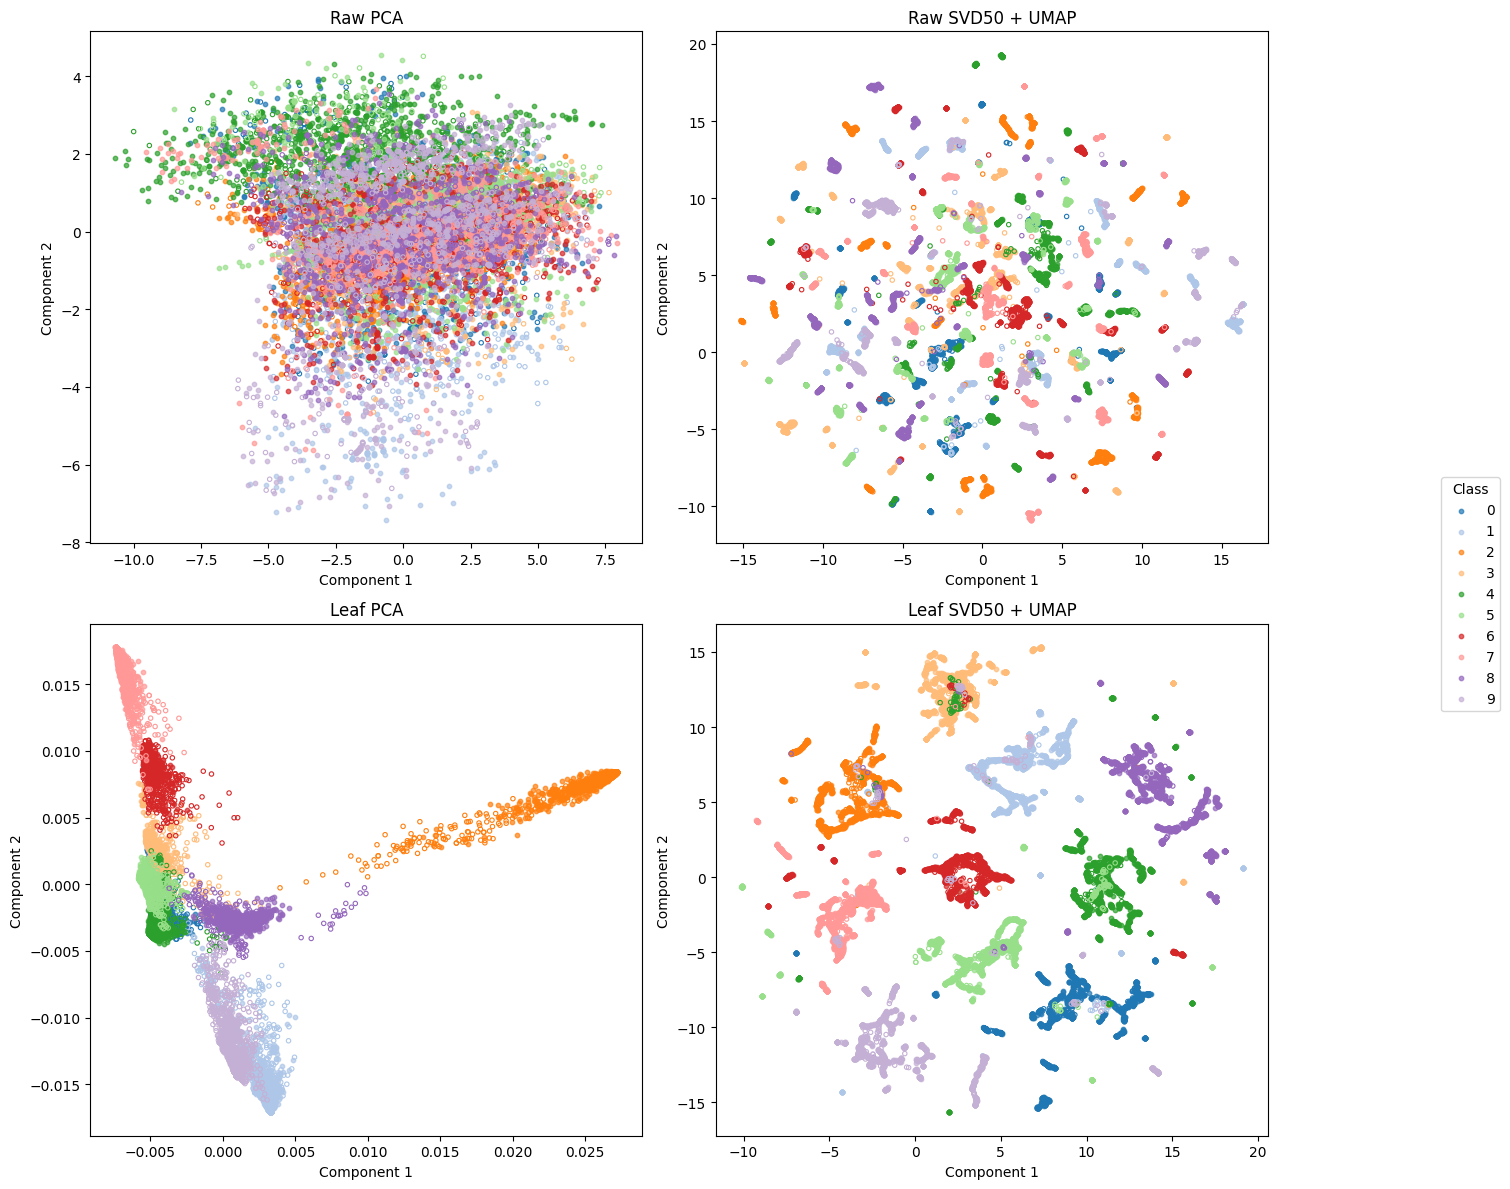

In [7]:
# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
pt_size_tr = 10
pt_size_te = 10
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
classes = np.unique(y_train)
cmap = plt.get_cmap("tab20")

plots = [
    ((x_pca_raw_train, x_pca_raw_test), "Raw PCA"),
    ((x_umap_raw_train, x_umap_raw_test), f"Raw SVD{SVD_DIM} + UMAP"),
    ((x_pca_leaf_train, x_pca_leaf_test), "Leaf PCA"),
    ((x_umap_leaf_train, x_umap_leaf_test), f"Leaf SVD{SVD_DIM} + UMAP"),
]

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for ((emb_train, emb_test), title), (r, c) in zip(plots, positions):
    ax = axes[r, c]

    for i, cls in enumerate(classes):
        color = cmap(i % 20)
        mask_tr = (y_train == cls)
        mask_te = (y_test == cls)

        # train points
        ax.scatter(
            emb_train[mask_tr, 0],
            emb_train[mask_tr, 1],
            s=pt_size_tr,
            alpha=0.7,
            color=color,
            label=str(cls),
        )

        # test points
        ax.scatter(
            emb_test[mask_te, 0],
            emb_test[mask_te, 1],
            s=pt_size_te,
            facecolors="none",
            edgecolors=[color],
            linewidths=0.8,
        )

    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# Single legend outside
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Class", loc="center right", bbox_to_anchor=(1.08, 0.5))

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

In [8]:
# w = fk._adapter.get_tree_weights(x_train)
# print("shape:", w.shape)
# print("sum:", w.sum())
# print("min:", w.min())
# print("max:", w.max())
# print("ratio max/min:", w.max() / max(w.min(), 1e-12))
# print("top 20 weights:", np.sort(w)[-20:])